In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
base_path = r'c:\Users\haruka\Desktop\AI수업\mcp-month-2\data'

In [3]:
fish_df = pd.read_csv(os.path.join(base_path, 'fish.csv'))

In [4]:
fish_input = fish_df[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish_df['Species'].to_numpy()

In [5]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target =\
train_test_split(fish_input, fish_target, random_state=42)

In [6]:
print(train_input.shape)
print(test_input.shape)

(119, 5)
(40, 5)


In [7]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [8]:
from sklearn.linear_model import SGDClassifier

In [9]:
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)

In [11]:
sc.fit(train_scaled, train_target);

c:\Users\haruka\Desktop\AI수업\mcp-month-2\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [12]:
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7899159663865546
0.825


In [19]:
sc.partial_fit(train_scaled, train_target);

In [20]:
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8403361344537815
0.8


In [21]:
sc = SGDClassifier(loss='log_loss', random_state=42)

In [23]:
train_score = []
test_score = []

for _ in range(0, 300):
  sc.partial_fit(train_scaled, train_target, classes=np.unique(train_target))
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

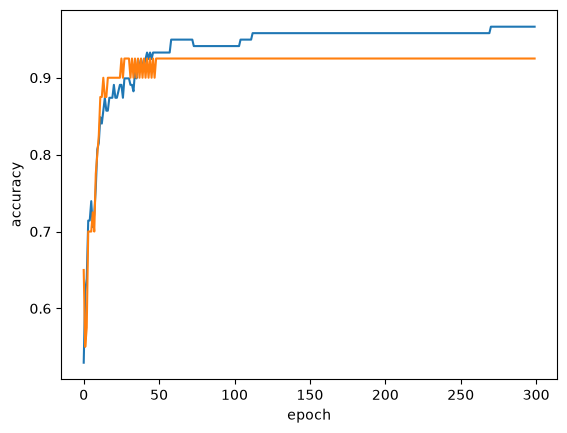

In [24]:
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [26]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target);

In [27]:
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925
